# SF$_6$-like - calculate observational network global- annual-mean, latitudinal gradient and seasonality

Calculate global-mean, latitudinal gradient and seasonality
based on the observational network.
We also perform an EOF analysis for the latitudinal gradient.
We also perform an EOF analysis for the seasonality change.

## Imports

In [1]:
from pathlib import Path

import cf_xarray.units
import matplotlib.axes
import matplotlib.pyplot as plt
import pint_xarray
import xarray as xr
from pydoit_nb.config_handling import get_config_for_step_id

import local.binned_data_interpolation
import local.binning
import local.latitudinal_gradient
import local.mean_preserving_interpolation
import local.raw_data_processing
import local.seasonality
import local.xarray_space
import local.xarray_time
from local.config import load_config_from_file

In [2]:
cf_xarray.units.units.define("ppm = 1 / 1000000")
cf_xarray.units.units.define("ppb = ppm / 1000")
cf_xarray.units.units.define("ppt = ppb / 1000")

pint_xarray.accessors.default_registry = pint_xarray.setup_registry(cf_xarray.units.units)

## Define branch this notebook belongs to

In [3]:
step: str = "calculate_sf6_like_monthly_fifteen_degree_pieces"

## Parameters

In [4]:
config_file: str = "../../dev-config-absolute.yaml"  # config file
step_config_id: str = "ch2cl2"  # config ID to select for this branch

In [5]:
# Parameters
config_file = "/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/output-bundles/v1.0.0/v1.0.0-config.yaml"
step_config_id = "ch3ccl3"


## Load config

In [6]:
config = load_config_from_file(Path(config_file))
config_step = get_config_for_step_id(config=config, step=step, step_config_id=step_config_id)

## Action

### Load data

In [7]:
interpolated_spatial: xr.DataArray = xr.load_dataarray(  # type: ignore
    config_step.observational_network_interpolated_file
).pint.quantify()
interpolated_spatial

Magnitude,[[[121.209 121.209 121.209 ... 153.80016666666668 158.874 158.874] [121.209 121.209 121.209 ... 157.77125 158.874 158.874] [121.209 121.209 121.209 ... 157.77124999999998 158.874 158.874] [121.209 121.209 121.209 ... 157.77125 158.874 158.874] [121.209 121.209 121.209 ... 156.86380303030305 158.874 158.874] [121.209 121.209 121.209 ... 155.0489090909091 158.874 158.874]] [[122.86 122.75 122.64 ... 151.671 151.671 151.671] [122.86 122.75 122.76599999999999 ... 151.671 151.671 151.671] [122.86 122.813 124.95878571428571 ... 151.671 151.671 151.671] [122.86 125.44918181818181 128.03836363636364 ... 151.671 151.671 151.671] [122.86 122.75 123.98959090909091 ... 151.671 151.671 151.671] [122.86 122.75 122.64 ... 151.671 151.671 151.671]] [[123.967 124.03720000000001 124.1074 ... 148.15133333333333 154.91 158.035] [123.967 124.0372 124.1074 ... 160.41633333333334 159.22566666666668 158.035] [123.967 124.03720000000001 126.75585714285714 ... 151.8371320754717 154.93316981132077 158.035] [123.967 127.06303773584906 130.15907547169812 ... 151.8313396226415 154.92737735849056 158.035] [123.967 124.0372 125.80333333333333 ... 151.82554716981133 154.92158490566038 158.035] [123.967 124.0372 124.1074 ... 151.81975471698112 154.91579245283017 158.035]] ... [[0.835 0.835 0.835 ... 0.8729583333333333 0.8726666666666666 0.877] [0.835 0.835 0.835 ... 0.8945000000000001 0.88575 0.877] [0.835 0.835 0.835 ... 0.867 0.872074074074074 0.877] [0.835 0.835 0.835 ... 0.8670740740740741 0.8722222222222222 0.877] [0.835 0.835 0.835 ... 0.8671481481481481 0.8723703703703704 0.877] [0.835 0.835 0.835 ... 0.8672222222222221 0.8725185185185185 0.877]] [[0.8115 0.8115 0.8115 ... 0.8688333333333333 0.876 0.8765000000000001] [0.8115 0.8115 0.8115 ... 0.888 0.88225 0.8765000000000001] [0.8115 0.8115 0.8115 ... 0.8935 0.884 0.8765000000000001] [0.8115 0.8115 0.8115 ... 0.8865740740740741 0.882 0.8765000000000001] [0.8115 0.8115 0.8115 ... 0.8796481481481482 0.88 0.8765000000000001] [0.8115 0.8115 0.8115 ... 0.8727222222222223 0.8780000000000001 0.8765000000000001]] [[0.815 0.815 0.815 ... 0.8725 0.8743333333333334 0.8743333333333334] [0.815 0.815 0.815 ... 0.89 0.8743333333333334 0.8743333333333334] [0.815 0.815 0.815 ... 0.898 0.8743333333333334 0.8743333333333334] [0.815 0.815 0.815 ... 0.8896666666666667 0.8743333333333334 0.8743333333333334] [0.815 0.815 0.815 ... 0.8813333333333334 0.8743333333333334 0.8743333333333334] [0.815 0.815 0.815 ... 0.873 0.8743333333333334 0.8743333333333334]]]
Units,ppt


In [8]:
if config_step.year_drop_observational_data_before_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        > config_step.year_drop_observational_data_before_and_including
    )

if config_step.year_drop_observational_data_after_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        < config_step.year_drop_observational_data_after_and_including
    )

interpolated_spatial

Magnitude,[[[121.209 121.209 121.209 ... 153.80016666666668 158.874 158.874] [121.209 121.209 121.209 ... 157.77125 158.874 158.874] [121.209 121.209 121.209 ... 157.77124999999998 158.874 158.874] [121.209 121.209 121.209 ... 157.77125 158.874 158.874] [121.209 121.209 121.209 ... 156.86380303030305 158.874 158.874] [121.209 121.209 121.209 ... 155.0489090909091 158.874 158.874]] [[122.86 122.75 122.64 ... 151.671 151.671 151.671] [122.86 122.75 122.76599999999999 ... 151.671 151.671 151.671] [122.86 122.813 124.95878571428571 ... 151.671 151.671 151.671] [122.86 125.44918181818181 128.03836363636364 ... 151.671 151.671 151.671] [122.86 122.75 123.98959090909091 ... 151.671 151.671 151.671] [122.86 122.75 122.64 ... 151.671 151.671 151.671]] [[123.967 124.03720000000001 124.1074 ... 148.15133333333333 154.91 158.035] [123.967 124.0372 124.1074 ... 160.41633333333334 159.22566666666668 158.035] [123.967 124.03720000000001 126.75585714285714 ... 151.8371320754717 154.93316981132077 158.035] [123.967 127.06303773584906 130.15907547169812 ... 151.8313396226415 154.92737735849056 158.035] [123.967 124.0372 125.80333333333333 ... 151.82554716981133 154.92158490566038 158.035] [123.967 124.0372 124.1074 ... 151.81975471698112 154.91579245283017 158.035]] ... [[0.835 0.835 0.835 ... 0.8729583333333333 0.8726666666666666 0.877] [0.835 0.835 0.835 ... 0.8945000000000001 0.88575 0.877] [0.835 0.835 0.835 ... 0.867 0.872074074074074 0.877] [0.835 0.835 0.835 ... 0.8670740740740741 0.8722222222222222 0.877] [0.835 0.835 0.835 ... 0.8671481481481481 0.8723703703703704 0.877] [0.835 0.835 0.835 ... 0.8672222222222221 0.8725185185185185 0.877]] [[0.8115 0.8115 0.8115 ... 0.8688333333333333 0.876 0.8765000000000001] [0.8115 0.8115 0.8115 ... 0.888 0.88225 0.8765000000000001] [0.8115 0.8115 0.8115 ... 0.8935 0.884 0.8765000000000001] [0.8115 0.8115 0.8115 ... 0.8865740740740741 0.882 0.8765000000000001] [0.8115 0.8115 0.8115 ... 0.8796481481481482 0.88 0.8765000000000001] [0.8115 0.8115 0.8115 ... 0.8727222222222223 0.8780000000000001 0.8765000000000001]] [[0.815 0.815 0.815 ... 0.8725 0.8743333333333334 0.8743333333333334] [0.815 0.815 0.815 ... 0.89 0.8743333333333334 0.8743333333333334] [0.815 0.815 0.815 ... 0.898 0.8743333333333334 0.8743333333333334] [0.815 0.815 0.815 ... 0.8896666666666667 0.8743333333333334 0.8743333333333334] [0.815 0.815 0.815 ... 0.8813333333333334 0.8743333333333334 0.8743333333333334] [0.815 0.815 0.815 ... 0.873 0.8743333333333334 0.8743333333333334]]]
Units,ppt


### Drop out any years that have nan

These break everything later on

In [9]:
interpolated_spatial_no_year_with_nan = local.xarray_time.convert_time_to_year_month(
    interpolated_spatial
).dropna("year")
if interpolated_spatial_no_year_with_nan["year"].shape[0] != (
    interpolated_spatial_no_year_with_nan["year"].max()
    - interpolated_spatial_no_year_with_nan["year"].min()
    + 1
):
    msg = f"Missing years, this will not end well {interpolated_spatial_no_year_with_nan['year'].values=}"
    raise AssertionError(msg)

interpolated_spatial_no_year_with_nan

<xarray.DataArray 'ch3ccl3' (lon: 6, lat: 12, year: 31, month: 12)> Size: 214kB
<Quantity([[[[113.5455     112.46833333 113.21       ... 114.38
    109.398      107.21966667]
   [103.325      103.093      103.365      ... 100.485
     98.139       97.986     ]
   [ 94.912       93.389       91.9335     ...  86.543
     86.72        84.7595    ]
   ...
   [  1.16         1.1205       1.107      ...   1.075
      1.07333333   1.0475    ]
   [  1.032        1.01         0.9835     ...   0.955
      0.936        0.9215    ]
   [  0.9085       0.893        0.857      ...   0.8395
      0.835        0.8115    ]]

  [[113.5455     112.46833333 113.21       ... 112.3075
    108.63394444 107.21966667]
   [103.325      103.093      102.68405556 ...  99.59208333
     97.88208333  97.986     ]
   [ 94.912       93.389       91.9335     ...  86.543
     85.86316667  84.152     ]
...
   [  1.24633333   1.23658333   1.23746667 ...   1.11875
      1.12091667   1.10825   ]
   [  1.10508333   1.11144444   1.09283333 ...   0.99496667
      1.00741667   1.0025    ]
   [  0.9901875    0.98575      0.981125   ...   0.87468889
      0.87251852   0.878     ]]

  [[137.808      137.9625     136.995      ... 124.154
    122.88266667 125.163     ]
   [123.272      120.688      121.829      ... 108.824
    108.148      107.734     ]
   [106.776      105.536      104.975      ...  92.644
     91.0515      89.054     ]
   ...
   [  1.25625      1.25416667   1.2618     ...   1.118375
      1.12283333   1.1151    ]
   [  1.108875     1.10775      1.1055     ...   1.0015
      1.0114       1.01      ]
   [  0.9902       0.98975      0.986      ...   0.8748
      0.877        0.8765    ]]]], 'ppt')>
Coordinates:
  * year     (year) int64 248B 1994 1995 1996 1997 1998 ... 2021 2022 2023 2024
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 96B -82.5 -67.5 -52.5 -37.5 ... 37.5 52.5 67.5 82.5
  * lon      (lon) float64 48B -150.0 -90.0 -30.0 30.0 90.0 150.0
Attributes:
    description:  Interpolated spatial data

In [10]:
interpolated_spatial_nan_free = local.xarray_time.convert_year_month_to_time(
    interpolated_spatial_no_year_with_nan
)
interpolated_spatial_nan_free

Magnitude,[[[113.5455 112.46833333333332 113.21 ... 0.8394999999999999 0.835 0.8115] [113.5455 112.46833333333332 113.21 ... 0.83875 0.835 0.8115] [113.5455 112.46833333333332 113.21 ... 0.838 0.835 0.8115] ... [132.92866666666666 130.23725 134.01366666666667 ... 0.8919333333333335 0.8729583333333333 0.8688333333333333] [137.808 134.099875 136.995 ... 0.8742000000000001 0.8726666666666666 0.876] [137.808 137.96249999999998 136.995 ... 0.8747999999999999 0.877 0.8765000000000001]] [[113.5455 112.46833333333332 113.21 ... 0.8394999999999999 0.835 0.8115] [113.5455 112.46833333333332 113.21 ... 0.8387499999999999 0.835 0.8115] [113.5455 112.46833333333332 113.21 ... 0.8380964912280701 0.835 0.8115] ... [134.39925 136.69016666666664 135.11200000000002 ... 0.87 0.8945000000000001 0.888] [137.808 137.3263333333333 136.995 ... 0.8724 0.88575 0.88225] [137.808 137.96249999999998 136.995 ... 0.8747999999999999 0.877 0.8765000000000001]] [[113.5455 112.46833333333332 113.21 ... 0.8394999999999999 0.835 0.8115] [113.5455 112.46833333333332 113.21 ... 0.8387982456140349 0.835 0.8115] [113.5455 112.46833333333332 113.21 ... 0.8382412280701754 0.835 0.8115] ... [134.39925 131.41341666666665 135.112 ... 0.878 0.867 0.8935] [137.808 134.29590277777774 136.995 ... 0.8761555555555555 0.872074074074074 0.884] [137.808 137.96249999999998 136.995 ... 0.8747999999999999 0.877 0.8765000000000001]] [[113.5455 112.46833333333332 113.21 ... 0.8394999999999999 0.835 0.8115] [113.5455 112.46833333333332 113.21 ... 0.8430595238095238 0.835 0.8115] [113.5455 112.46833333333332 113.21 ... 0.8466190476190475 0.835 0.8115] ... [134.39925 130.62930555555556 135.11200000000002 ... 0.8756462962962964 0.8670740740740741 0.8865740740740741] [137.808 134.09987499999997 136.995 ... 0.8756666666666667 0.8722222222222222 0.882] [137.808 137.96249999999998 136.995 ... 0.8747999999999999 0.877 0.8765000000000001]] [[113.5455 112.46833333333332 113.21 ... 0.8394999999999999 0.835 0.8115] [113.5455 112.46833333333332 113.21 ... 0.8387499999999999 0.835 0.8115] [113.5455 112.46833333333332 113.21 ... 0.8401547619047618 0.835 0.8115] ... [134.39925 130.23725 134.72451515151516 ... 0.8732925925925926 0.8671481481481481 0.8796481481481482] [137.808 134.099875 136.995 ... 0.8751777777777778 0.8723703703703704 0.88] [137.808 137.96249999999998 136.995 ... 0.8747999999999999 0.877 0.8765000000000001]] [[113.5455 112.46833333333332 113.21 ... 0.8394999999999999 0.835 0.8115] [113.5455 112.46833333333332 113.21 ... 0.8387499999999999 0.835 0.8115] [113.5455 112.46833333333332 113.21 ... 0.838 0.835 0.8115] ... [134.39925 130.23725 133.94954545454544 ... 0.8709388888888889 0.8672222222222221 0.8727222222222223] [137.808 134.09987499999997 136.995 ... 0.874688888888889 0.8725185185185185 0.8780000000000001] [137.808 137.96249999999998 136.995 ... 0.8747999999999999 0.877 0.8765000000000001]]]
Units,ppt


### Longitudinal-mean

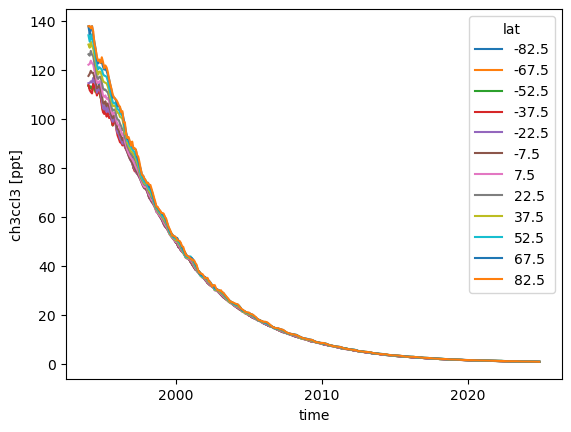

In [11]:
lon_mean = interpolated_spatial_nan_free.mean(dim="lon")
lon_mean.plot(hue="lat")  # type: ignore

### Global-, annual-mean

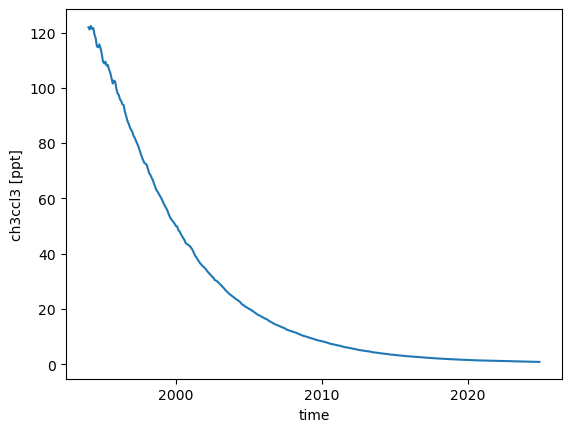

In [12]:
global_mean = local.xarray_space.calculate_global_mean_from_lon_mean(lon_mean)
global_mean.plot()  # type: ignore

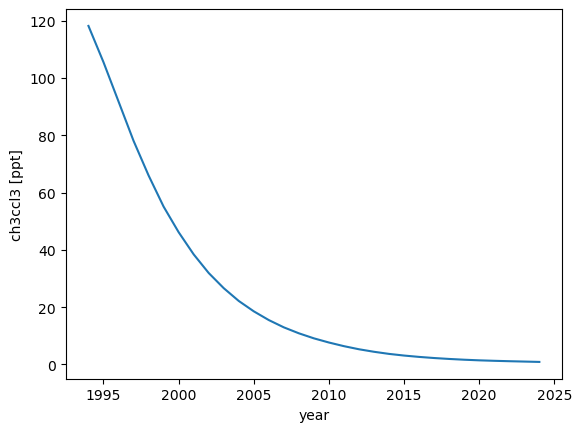

In [13]:
global_annual_mean = global_mean.groupby("time.year").mean()
global_annual_mean.plot()  # type: ignore

### Latitudinal gradient

In [14]:
(
    lat_residuals_annual_mean,
    lat_gradient_full_eofs_pcs,
) = local.latitudinal_gradient.calculate_eofs_pcs(lon_mean, global_mean)
lat_gradient_full_eofs_pcs

<xarray.Dataset> Size: 5kB
Dimensions:               (lat: 12, eof: 12, year: 31)
Coordinates:
  * lat                   (lat) float64 96B -82.5 -67.5 -52.5 ... 52.5 67.5 82.5
  * eof                   (eof) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * year                  (year) int64 248B 1994 1995 1996 ... 2022 2023 2024
Data variables:
    eofs                  (lat, eof) float64 1kB [ppt] 0.2196 ... -0.05329
    principal-components  (year, eof) float64 3kB [] -24.93 1.742 ... 4.891e-17

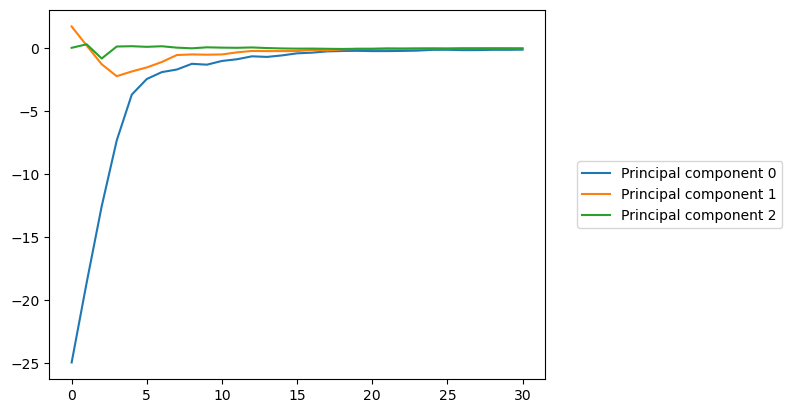

In [15]:
fig, ax = plt.subplots()
n_eofs_to_show = 3

for i in range(n_eofs_to_show):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).data.m,
        label=f"Principal component {i}",
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

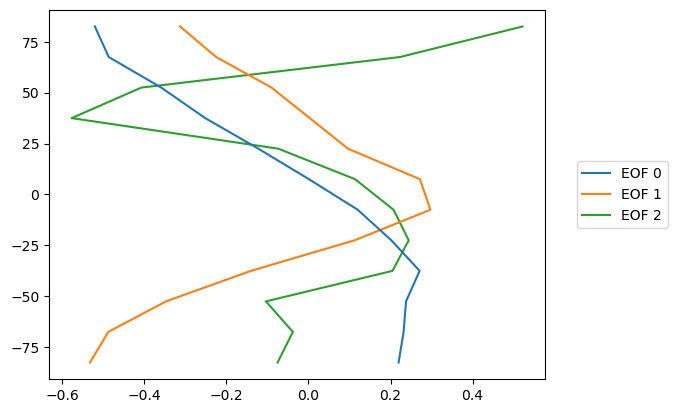

In [16]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["eofs"].sel(eof=i).data.m,
        lat_gradient_full_eofs_pcs["lat"].data,
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

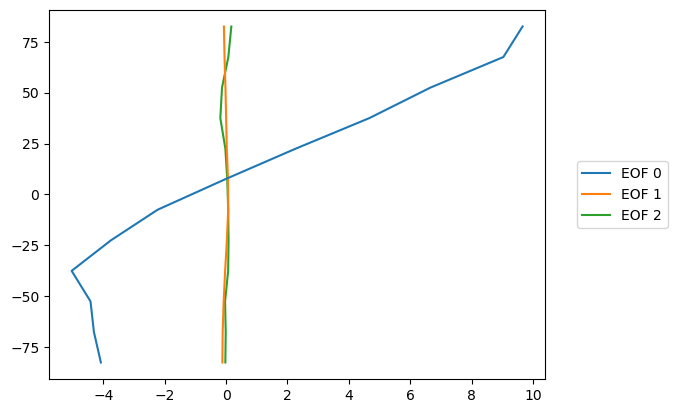

In [17]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).isel(year=1)
        @ lat_gradient_full_eofs_pcs["eofs"].sel(eof=i),
        lat_gradient_full_eofs_pcs["lat"],
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

In [18]:
lat_gradient_eofs_pcs = lat_gradient_full_eofs_pcs.sel(eof=range(config_step.lat_gradient_n_eofs_to_use))
lat_gradient_eofs_pcs

Magnitude,[[0.21959021698301412] [0.23181286880117183] [0.23774993349153675] [0.27083724740016346] [0.2018985844564096] [0.12014088039605957] [0.0013984858577815347] [-0.12199219259340477] [-0.2511039696471608] [-0.35840098867787445] [-0.48618688693791756] [-0.5198095837482111]]
Units,ppt
Magnitude,[[-24.927096243010762] [-18.584773938071063] [-12.525596367369566] [-7.304305917650626] [-3.6677804160085974] [-2.42785740026476] [-1.8801500415789072] [-1.67453359868469] [-1.2215122672773941] [-1.2894905172259674] [-0.9945355713451027] [-0.8596417816479215] [-0.6262810633852762] [-0.6732263814500684] [-0.5544809495606543] [-0.38932585591067376] [-0.33537095646268633] [-0.23476122433678867] [-0.20446953097259404] [-0.1900803175638745] [-0.21232085776850737] [-0.21164535895580094] [-0.1973516473655316] [-0.17278255793843764] [-0.11254261522520478] [-0.10889288675321751] [-0.1356299269932274] [-0.13232473094788716] [-0.10904425728668499] [-0.11015253475004132] [-0.0991889836433478]]
Units,dimensionless


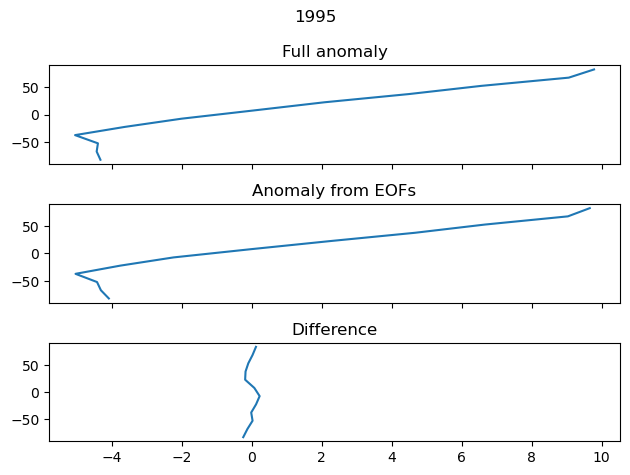

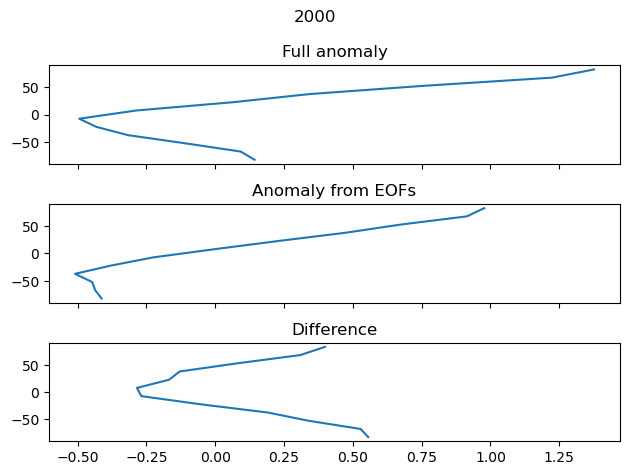

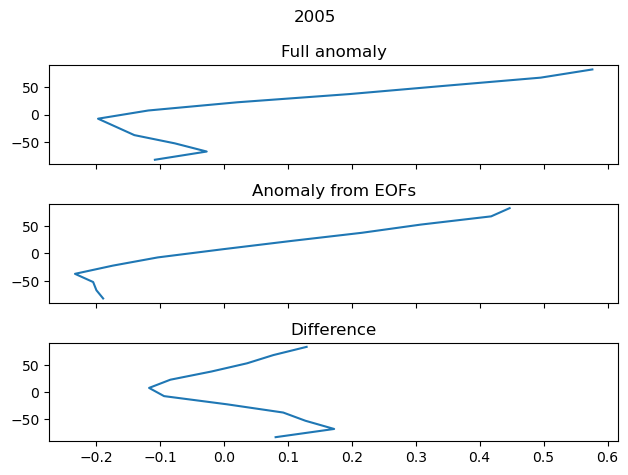

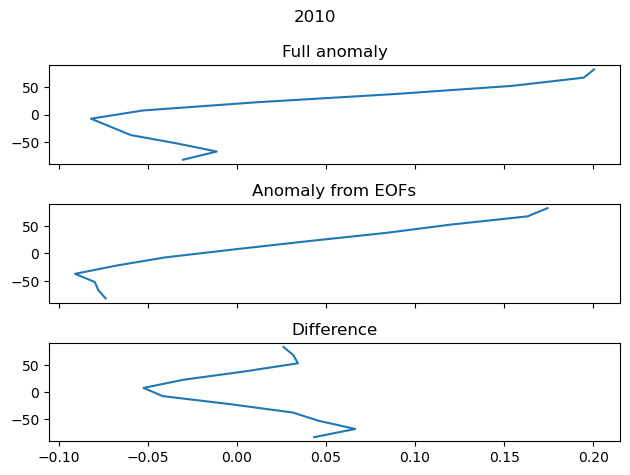

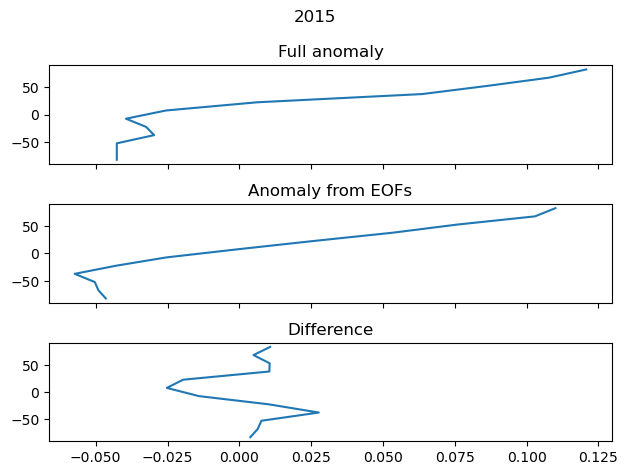

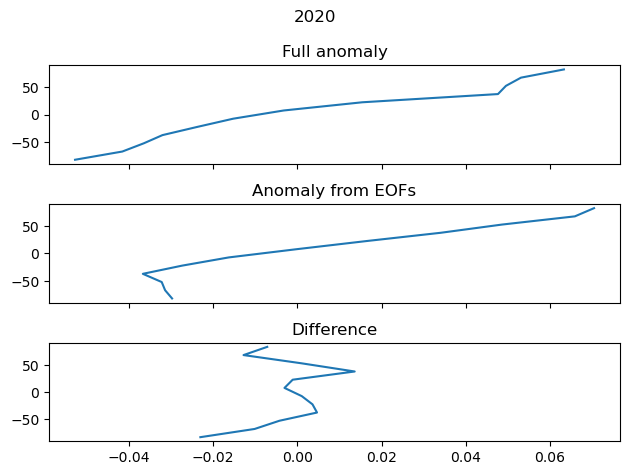

In [19]:
latitudinal_anomaly_from_eofs = lat_gradient_eofs_pcs["principal-components"] @ lat_gradient_eofs_pcs["eofs"]

for year in latitudinal_anomaly_from_eofs["year"]:
    if year % 5:
        continue

    fig, axes = plt.subplots(nrows=3, sharex=True, sharey=True)
    if isinstance(axes, matplotlib.axes.Axes):
        raise TypeError(type(axes))

    selected = lat_residuals_annual_mean.sel(year=year)
    axes[0].plot(selected.data.m, lat_residuals_annual_mean.lat)
    axes[0].set_title("Full anomaly")

    selected_eofs = latitudinal_anomaly_from_eofs.sel(year=year)
    axes[1].plot(selected_eofs.data.m, latitudinal_anomaly_from_eofs.lat)
    axes[1].set_title("Anomaly from EOFs")

    axes[2].plot(selected.data.m - selected_eofs.data.m, lat_residuals_annual_mean.lat)
    axes[2].set_title("Difference")

    axes[0].set_ylim([-90, 90])

    plt.suptitle(str(int(year)))
    plt.tight_layout()
    plt.show()

### Seasonality

In [20]:
(
    seasonality,
    relative_seasonality,
    lon_mean_ym_monthly_anomalies,
) = local.seasonality.calculate_seasonality(
    lon_mean=lon_mean,
    global_mean=global_mean,
)

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore
/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/.pixi/envs/all-dev/lib/python3.11/importlib/__init__.py:126: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  return _bootstrap._gcd_import(name[level:], package, level)


Calculating output values:   0%|                                                                                                                                                                                      | 0/372 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 372/372 [00:00<00:00, 18931.08it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/372 [00:00<?, ?it/s]

...

Calculating output values:   0%|                                                                                                                                                                                      | 0/372 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 372/372 [00:00<00:00, 19985.67it/s]

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/372 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 372/372 [00:00<00:00, 20295.55it/s]

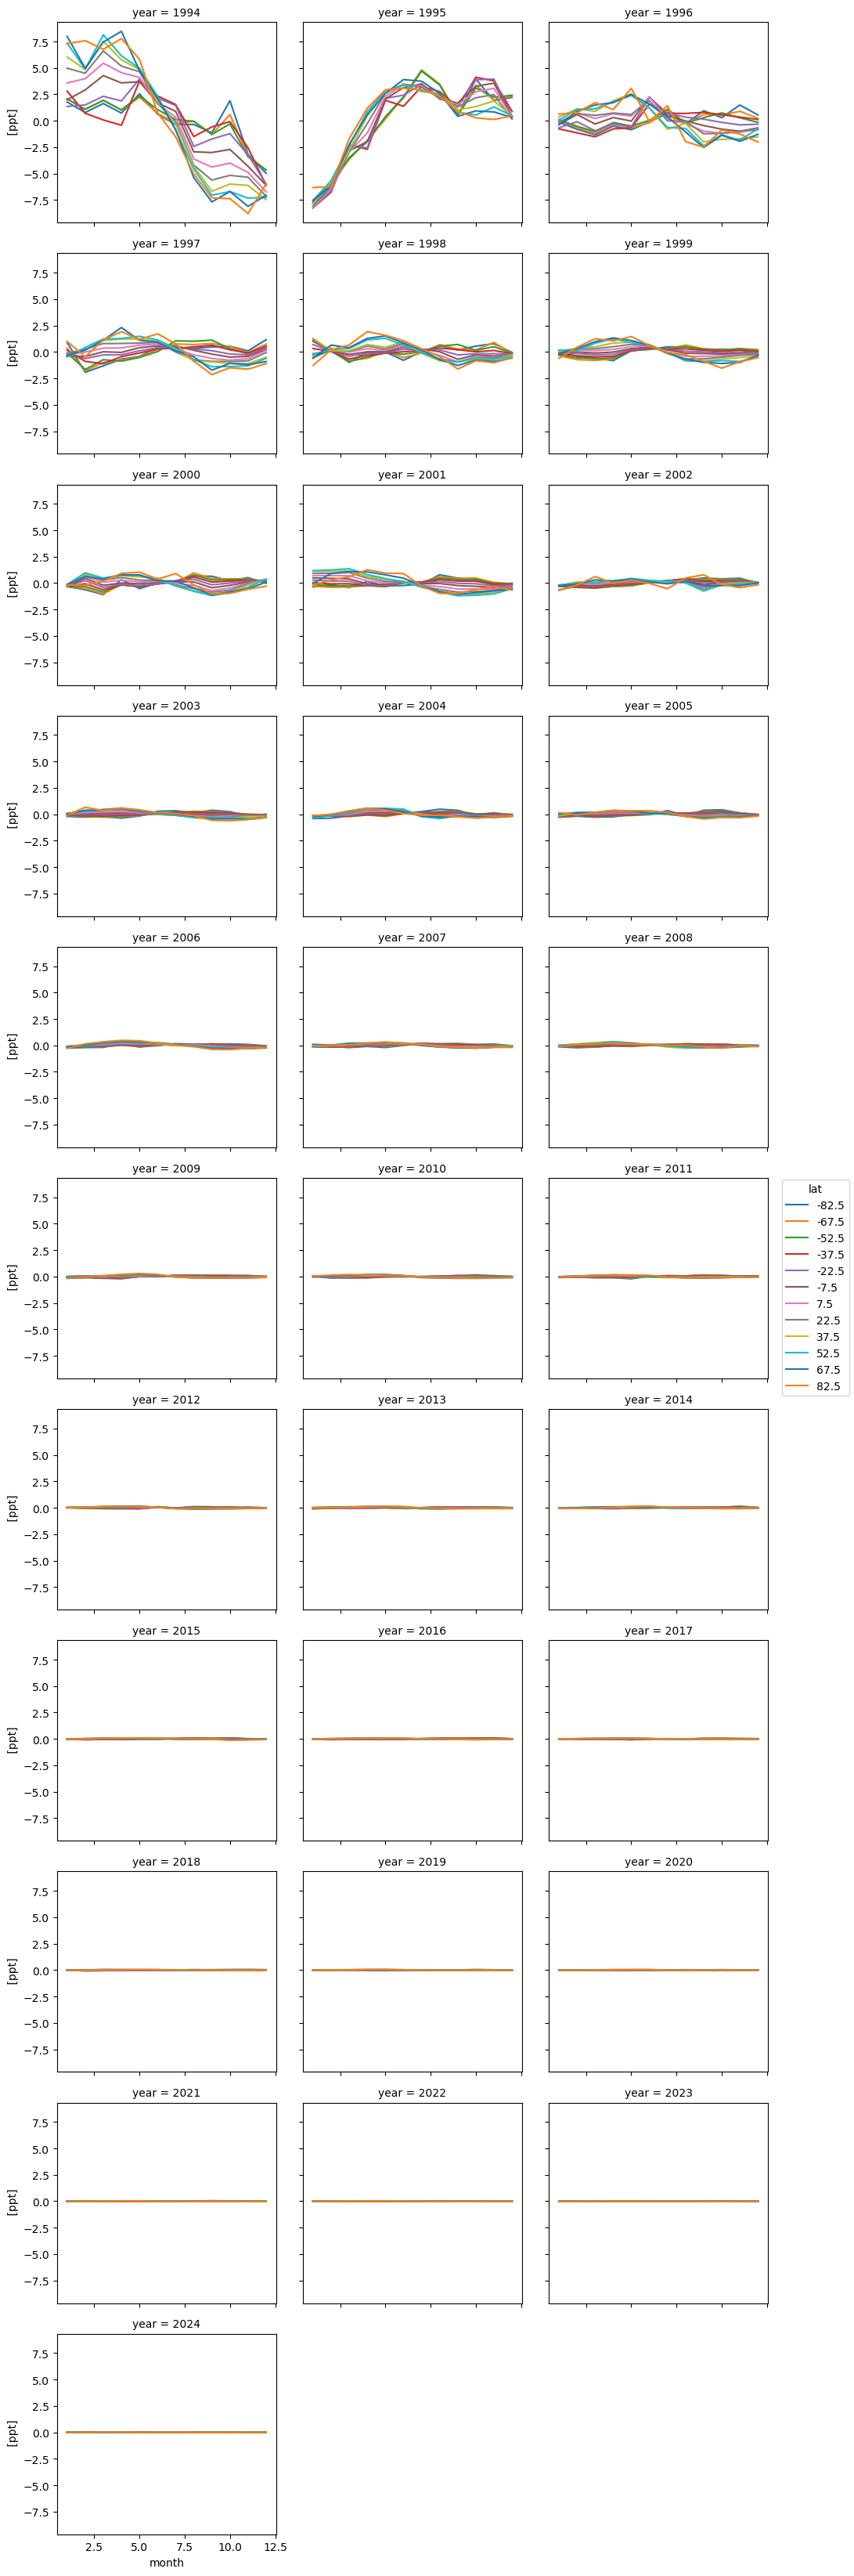

In [21]:
lon_mean_ym_monthly_anomalies.plot.line(hue="lat", col="year", col_wrap=3)

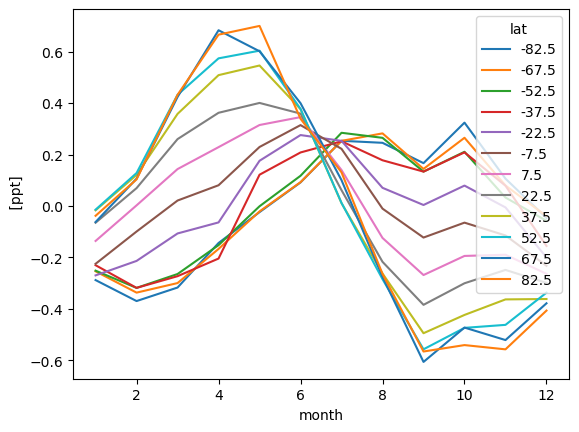

In [22]:
seasonality.plot.line(hue="lat")

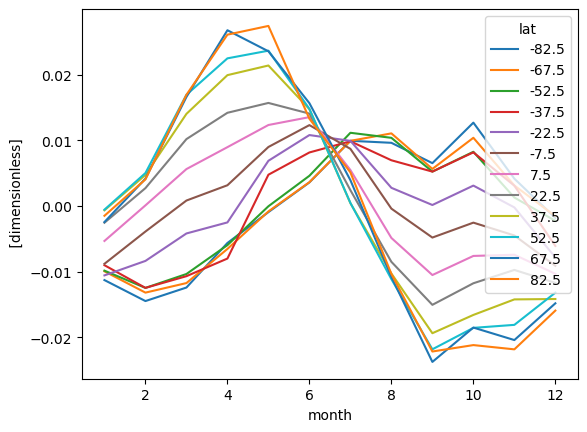

In [23]:
relative_seasonality.plot.line(hue="lat")

### Save

In [24]:
config_step.observational_network_global_annual_mean_file.parent.mkdir(exist_ok=True, parents=True)
global_annual_mean.pint.dequantify().to_netcdf(config_step.observational_network_global_annual_mean_file)
global_annual_mean

Magnitude,[118.12856325284672 105.48645277972018 91.7770063052612 78.04717875781849 65.9625224891055 55.080714843754826 46.15865046912173 38.42241852358016 31.91729513204066 26.626592742073388 22.162144297622262 18.5441659628944 15.492405816335753 12.950797694530777 10.874616204910074 9.115858309089312 7.659261162691396 6.385994427757229 5.305758167415629 4.4275109237950785 3.689574974212833 3.1108582947596464 2.6404053735647284 2.247763054375729 1.926933099929765 1.6587246691155928 1.4433025482299309 1.2791111063298664 1.1391351140241517 1.0145074471967874 0.8898747650228439]
Units,ppt


In [25]:
config_step.observational_network_latitudinal_gradient_eofs_file.parent.mkdir(exist_ok=True, parents=True)
lat_gradient_eofs_pcs.pint.dequantify().to_netcdf(
    config_step.observational_network_latitudinal_gradient_eofs_file
)
lat_gradient_eofs_pcs

Magnitude,[[0.21959021698301412] [0.23181286880117183] [0.23774993349153675] [0.27083724740016346] [0.2018985844564096] [0.12014088039605957] [0.0013984858577815347] [-0.12199219259340477] [-0.2511039696471608] [-0.35840098867787445] [-0.48618688693791756] [-0.5198095837482111]]
Units,ppt
Magnitude,[[-24.927096243010762] [-18.584773938071063] [-12.525596367369566] [-7.304305917650626] [-3.6677804160085974] [-2.42785740026476] [-1.8801500415789072] [-1.67453359868469] [-1.2215122672773941] [-1.2894905172259674] [-0.9945355713451027] [-0.8596417816479215] [-0.6262810633852762] [-0.6732263814500684] [-0.5544809495606543] [-0.38932585591067376] [-0.33537095646268633] [-0.23476122433678867] [-0.20446953097259404] [-0.1900803175638745] [-0.21232085776850737] [-0.21164535895580094] [-0.1973516473655316] [-0.17278255793843764] [-0.11254261522520478] [-0.10889288675321751] [-0.1356299269932274] [-0.13232473094788716] [-0.10904425728668499] [-0.11015253475004132] [-0.0991889836433478]]
Units,dimensionless


In [26]:
# Use relative seasonality
config_step.observational_network_seasonality_file.parent.mkdir(exist_ok=True, parents=True)
relative_seasonality.pint.dequantify().to_netcdf(config_step.observational_network_seasonality_file)
relative_seasonality

Magnitude,[[-0.011273640560427645 -0.014465838361143981 -0.012407741563782064 -0.005627497119492614 -0.0009293035693378281 0.003593148760792539 0.009926822716805431 0.00961942031861443 0.006523490128289467 0.012688219933737985 0.004161853600496823 -0.0018089397781649275] [-0.009940611710853845 -0.013182814596176776 -0.011727880843793835 -0.006531273875085211 -0.0008237945028844555 0.003626549994510508 0.009917575996686748 0.011055587156363317 0.005646575743413436 0.010385268265086902 0.0031241086866110215 -0.0015492957757030391] [-0.009838986144197218 -0.012464733271242945 -0.010349296585150932 -0.005953577107089451 -3.862583079630641e-05 0.004602508369682134 0.011145229952977431 0.010378717012959749 0.005233223216017985 0.008252479751794203 0.0012894582832424747 -0.0022564027989222324] [-0.009009114008358778 -0.012460303028793142 -0.010679200787627966 -0.00799542806783578 0.004763401209429482 0.008151234583345157 0.009851274058174136 0.006961852851582744 0.005236503897417201 0.008165730271362458 0.003091523514925533 -0.006077479788529904] [-0.01055824870166939 -0.008356572812792368 -0.004177605125965246 -0.002496869119153841 0.006885579150139672 0.010799116119648797 0.009918320317088657 0.0027699125843489913 0.0001559119685573949 0.003107552589631399 -0.00021417517322916004 -0.00783292737932632] [-0.008797134543639683 -0.0038842405962039557 0.0008338103511398463 0.003160627702570177 0.008985121344255031 0.012313826189259868 0.008700906415460966 -0.0003992974092177254 -0.004800744195543261 -0.0025306625641956806 -0.004480737988719273 -0.009101480668809468] [-0.0053185414509947055 9.918316582250677e-05 0.005621872424221832 0.008959427924155812 0.012331081933505664 0.0135298949221982 0.005476628916344388 -0.004861850958542871 -0.01050542822263846 -0.007598183821176826 -0.007416166500307077 -0.010317924807374345] [-0.002541923852860197 0.00272369553651195 0.010183823890370668 0.014189867755915452 0.015688473042146593 0.014065277216452659 0.0024084667773560226 -0.008494414525832 -0.015040232169364148 -0.011757500540627968 -0.009728345335315311 -0.011697194769002018] [-0.000652500180202278 0.004726061154089992 0.014023556188330908 0.019919358146572884 0.021386339517540362 0.014739401131480083 0.0004346741678390872 -0.010272058170758576 -0.019359437287956215 -0.016577401095015678 -0.014214300905254709 -0.014153699701021382] [-0.0005561522035711637 0.005020314170975441 0.016931363156441972 0.022475025399086968 0.023642959887388782 0.014782907598318835 0.0004668106215332493 -0.011133322780757581 -0.021808401959760956 -0.018545712464016473 -0.018089125109387632 -0.013186673297386398] [-0.002438655833523882 0.004166923476619969 0.016602438034976363 0.026752695498095683 0.023549104688547012 0.015650895858102074 0.003933320822651222 -0.010775044615575198 -0.02372962460387768 -0.018501903262497225 -0.020401768657748977 -0.014808389054536849] [-0.0014863073949702222 0.004051353874841919 0.016924391484081563 0.026081088275611022 0.027410754976691182 0.013281277254359604 0.00512183011085183 -0.010340027744794358 -0.02214468244949506 -0.02116780876360531 -0.021815890541125194 -0.01591598655766966]]
Units,dimensionless
